N= 2, τ=0.6822, Eb=1.058141, Ergotropy=1.020168, erg/Eb=0.964113651149, Variance=5.7360130333e-01, ThirdMoment=2.7069069669e+00, Skewness=-2.5398228176e-01
N= 3, τ=0.5807, Eb=1.683140, Ergotropy=1.636665, erg/Eb=0.972388170139, Variance=8.8272458818e-01, ThirdMoment=8.4386114649e+00, Skewness=-3.3719738990e-01
N= 4, τ=0.5158, Eb=2.323216, Ergotropy=2.270698, erg/Eb=0.977394390424, Variance=1.1937538485e+00, ThirdMoment=1.9355031661e+01, Skewness=-3.7170886247e-01
N= 5, τ=0.4696, Eb=2.973274, Ergotropy=2.916091, erg/Eb=0.980767557910, Variance=1.5059273173e+00, ThirdMoment=3.7256270476e+01, Skewness=-3.8702141779e-01
N= 6, τ=0.4344, Eb=3.629995, Ergotropy=3.569077, erg/Eb=0.983217925261, Variance=1.8187600085e+00, ThirdMoment=6.3974105035e+01, Skewness=-3.9292601571e-01
N= 7, τ=0.4065, Eb=4.292903, Ergotropy=4.228811, erg/Eb=0.985070184249, Variance=2.1321818007e+00, ThirdMoment=1.0144478975e+02, Skewness=-3.9446706151e-01
N= 8, τ=0.3835, Eb=4.959030, Ergotropy=4.892298, erg/Eb=0.986543

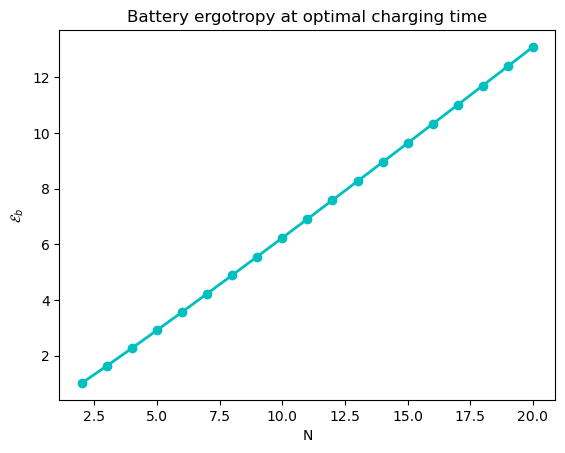

In [5]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

############
# parameters
############

N_arr = np.arange(2, 21, 1)
nmax = 80
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, (2*np.pi), 0.0001)

######################
# collective operators
######################

def collective_ops(N):
    Sp = qt.jmat(N/2, '+')
    Sm = Sp.dag()
    Sz = qt.jmat(N/2, 'z')
    HB = Sz + (N/2)*qt.qeye(N+1)
    return Sp, Sm, HB

############################
# Tavis-Cummings Hamiltonian
############################

def tavis_cummings(N, nmax, ω, ω0, g):
    a = qt.destroy(nmax)
    Sp, Sm, HB = collective_ops(N)
    H = (ω * qt.tensor(a.dag()*a, qt.qeye(N+1)) + ω0 * qt.tensor(qt.qeye(nmax), HB) + g * (qt.tensor(a, Sp) + qt.tensor(a.dag(), Sm)))
    return H, HB

################
# Initial state
################

def initial_state(N, nmax, state):
    if state=="coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state=="fock":
        psiA = qt.basis(nmax, N)
    psiB = qt.basis(N+1, N)  
    return qt.tensor(psiA, psiB)

#########################################
# optimal charging time τ (maximum power)
#########################################

τ_list = []

for N in N_arr:
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    HB_full = qt.tensor(qt.qeye(nmax), HB)
    psi0 = initial_state(N, nmax, "coherent")

    opts = qt.Options(atol=1e-16, rtol=1e-14)         ## ODE solver options
    res = qt.sesolve(H, psi0, tlist, e_ops=HB_full, options=opts)
    EB = np.array(res.expect[0])
    power = EB / tlist

    τ_list.append(tlist[np.argmax(power)])

###########################################
# Calculation of ergotropy and fluctuations
###########################################

E_ratio, E_ergo, E_var, F_ratio, FE_ratio, E_moment3, E_skewness = [], [], [], [], [], [], []

for i, N in enumerate(N_arr):

    τ = τ_list[i]
    
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    
    psi0 = initial_state(N, nmax, "coherent")

    res = qt.sesolve(H, psi0, [0, τ], options=opts)
    
    rho_b = res.states[-1].ptrace(1)

    E_B = qt.expect(HB, rho_b)
    
    r_vals, r_vecs = rho_b.eigenstates()

    # Clip numerical noise to prevent negative probabilities
    r_vals = np.maximum(r_vals, 0) 
    # Renormalize 
    r_vals = r_vals / np.sum(r_vals)
        
    idx = np.argsort(r_vals)[::-1]
    r_vals = r_vals[idx]
    r_vecs = [r_vecs[i] for i in idx]

    # assign degenerate energies 
    e_vals = np.array([0] + [ω0]*N)
    
    # e_vals = np.arange(N + 1) * ω0
    
    E_B = qt.expect(HB, rho_b)
    
    E_erg = E_B - sum(r_vals[j]*e_vals[j] for j in range(len(r_vals)))

    W_2 = (qt.expect(HB**2, rho_b) + sum(r_vals[j]*(e_vals[j])**2 for j in range(len(r_vals)))) - 2 * sum(e_vals[i]*r_vals[i]*qt.expect(HB, r_vecs[i]) for i in range(len(r_vals)))

    ΔE2 = W_2 - (E_erg)**2

    #########################################################
    # Third moment of the ergotropy operator
    # <(E_B)^3> = Tr[rho (H - H_pass)^3]
    #########################################################

    # ---------- first term ----------
    # Tr[rho H_B^3]
    term1 = qt.expect(HB**3, rho_b)

    # ---------- second term ----------
    # -3 * Σ_j ε_j r_j <r_j|H_B^2|r_j>
    term2 = -3 * sum(e_vals[j] * r_vals[j] * qt.expect(HB**2, r_vecs[j]) for j in range(len(r_vals)))

    # ---------- third term ----------
    # +3 * Σ_j ε_j^2 r_j <r_j|H_B|r_j>
    term3 = 3 * sum((e_vals[j]**2) * r_vals[j] * qt.expect(HB, r_vecs[j]) for j in range(len(r_vals)))

    # ---------- fourth term ----------
    # - Σ_j r_j ε_j^3
    term4 = -sum(r_vals[j] * (e_vals[j]**3) for j in range(len(r_vals)))

    # Third raw moment
    W_3 = term1 + term2 + term3 + term4

    #########################################################
    # Third central moment (skewness numerator)
    # μ3 = <E^3> - 3<E^2><E> + 2<E>^3
    #########################################################

    mu3 = W_3 - 3 * W_2 * E_erg + 2 * (E_erg**3)

    #########################################################
    # Normalized skewness
    #########################################################

    if ΔE2 > 1e-14:
        skewness = mu3 / (ΔE2**1.5)
    else:
        skewness = 0.0
    
    ΔE = np.sqrt(ΔE2)

    Ratio = E_erg / E_B
    
    E_ergo.append(E_erg)

    E_var.append(ΔE2)
    
    E_ratio.append(Ratio)
    
    F_ratio.append(ΔE / E_erg)

    FE_ratio.append(ΔE / E_B)

    E_moment3.append(W_3)

    E_skewness.append(skewness)


    print(f"N={N:2d}, τ={τ:.4f}, Eb={E_B:.6f}, Ergotropy={E_erg:.6f}, erg/Eb={Ratio:.12f}, Variance={ΔE2:.10e}, ThirdMoment={W_3:.10e}, Skewness={skewness:.10e}")

###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.plot(N_arr, E_ergo, 'o-', color='c', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
#plt.savefig("OP1")
plt.show()

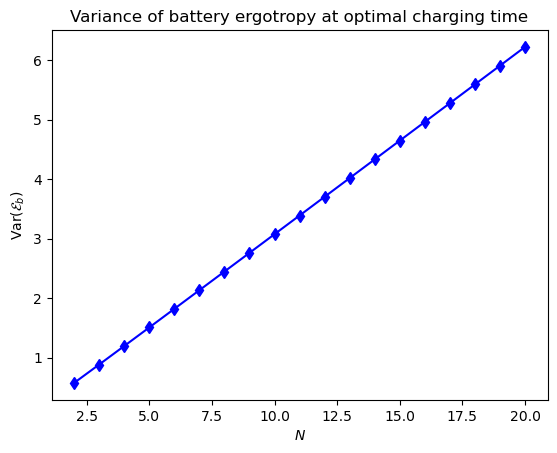

In [6]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, E_var, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
#plt.savefig("OP2")
plt.show()

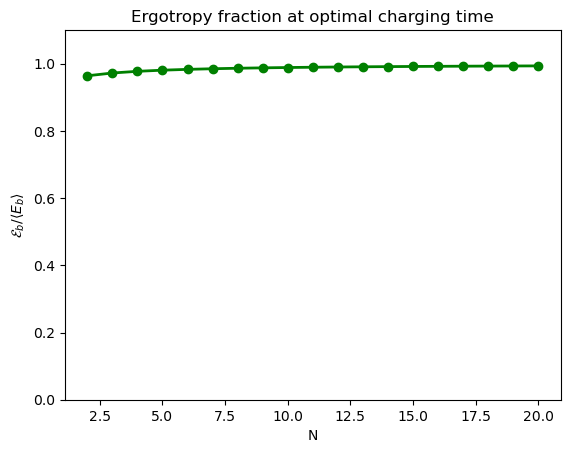

In [8]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
############################################################
    
plt.plot(N_arr, E_ratio, 'o-', color='g', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
# plt.savefig("OP3")
plt.show()

N= 2, τ=0.6822, Relative Fluctuation =0.742391876427, Relative Fluctuation with Eb =0.715750142565
N= 3, τ=0.5807, Relative Fluctuation =0.574053974810, Relative Fluctuation with Eb =0.558203294127
N= 4, τ=0.5158, Relative Fluctuation =0.481169352761, Relative Fluctuation with Eb =0.470292226233
N= 5, τ=0.4696, Relative Fluctuation =0.420824435350, Relative Fluctuation with Eb =0.412730953767
N= 6, τ=0.4344, Relative Fluctuation =0.377860794417, Relative Fluctuation with Eb =0.371519506324
N= 7, τ=0.4065, Relative Fluctuation =0.345297843623, Relative Fluctuation with Eb =0.340142610438
N= 8, τ=0.3835, Relative Fluctuation =0.319668080981, Relative Fluctuation with Eb =0.315366397352
N= 9, τ=0.3642, Relative Fluctuation =0.298783806981, Relative Fluctuation with Eb =0.295118518255
N=10, τ=0.3478, Relative Fluctuation =0.281288776036, Relative Fluctuation with Eb =0.278110972774
N=11, τ=0.3334, Relative Fluctuation =0.266512641177, Relative Fluctuation with Eb =0.263723871961
N=12, τ=0.

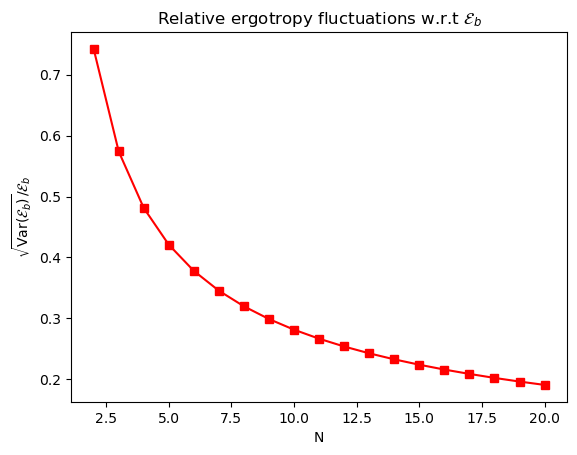

In [9]:
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.4f}, Relative Fluctuation ={F_ratio[idx]:.12f}, Relative Fluctuation with Eb ={FE_ratio[idx]:.12f}")


######################################################
# Plot fluctuations as a function of g for different N 
######################################################

plt.plot(N_arr, F_ratio, 's-', color='r')
plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
# plt.savefig("OP4")
plt.show()

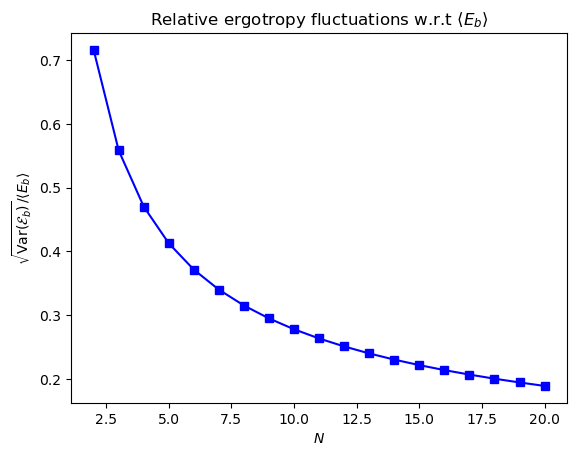

In [10]:
##########################################################################
# Plot fluctuations w.r.t battery energy as function of g for different N 
##########################################################################

plt.figure()
plt.plot(N_arr, FE_ratio, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
# plt.savefig("OP5")
plt.show()

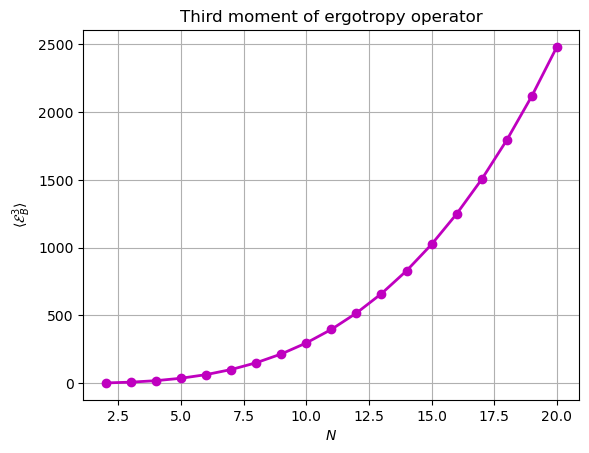

In [11]:
#############################################################
# Plot of third moment of ergotropy fluctuations
#############################################################

plt.figure()
plt.plot(N_arr, E_moment3, 'o-', color='m', linewidth=2)
plt.xlabel(r"$N$")
plt.ylabel(r"$\langle \mathcal{E}_B^3 \rangle$")
plt.title("Third moment of ergotropy operator")
plt.grid(True)
plt.show()

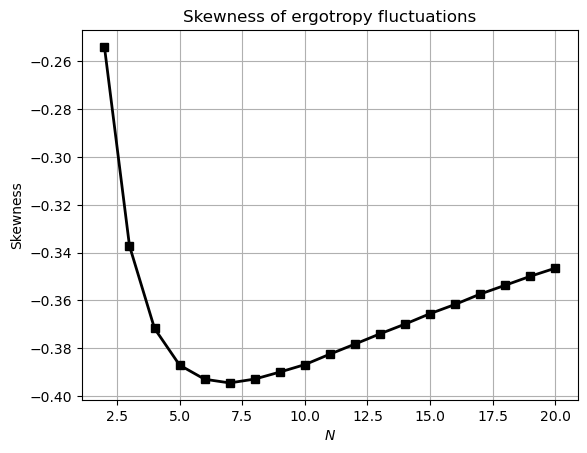

In [12]:
#############################################################
# Plot of skewness
#############################################################

plt.figure()
plt.plot(N_arr, E_skewness, 's-', color='k', linewidth=2)
plt.xlabel(r"$N$")
plt.ylabel(r"Skewness")
plt.title("Skewness of ergotropy fluctuations")
plt.grid(True)
plt.show()

Best fit parameters: A = 0.086152


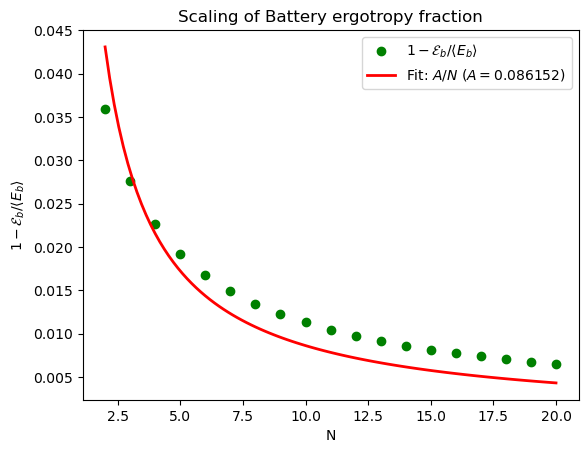

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# The fitting function
def asymptotic_fit(N, A):
    return (A / N)


y_data = 1 - np.array(E_ratio) 

# The curve fit

popt, pcov = curve_fit(asymptotic_fit, N_arr, y_data)
A_opt = popt[0]

print(f"Best fit parameters: A = {A_opt:.6f}")

# A smooth curve for the fit using the optimal parameters

N_smooth = np.linspace(min(N_arr), max(N_arr), 100)
y_fit = asymptotic_fit(N_smooth, A_opt)

# Plot the original data and the fitted curve

plt.plot(N_arr, y_data, 'o', color='g', markersize=6, label=r"$1 - \mathcal{E}_b / \langle E_b \rangle$")
plt.plot(N_smooth, y_fit, '-', color='r', linewidth=2, label=rf'Fit: $A/N$ ($A={A_opt:.6f}$)')

plt.xlabel("N")
plt.ylabel(r"$1 - \mathcal{E}_b / \langle E_b \rangle$")
plt.title("Scaling of Battery ergotropy fraction")
plt.legend()
# plt.savefig("OP6")
plt.show()

Best fit parameter: A = 0.109469


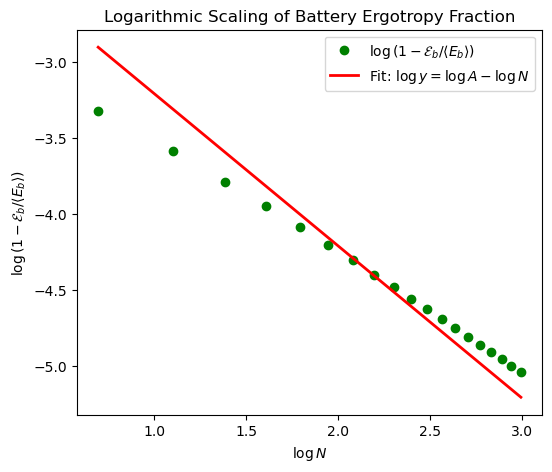

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Original data
y_data = 1 - np.array(E_ratio)

# Keep only positive values (required for logarithm)
mask = (N_arr > 0) & (y_data > 0)

N_fit = np.array(N_arr)[mask]
y_fit_data = y_data[mask]

# Take logarithms
log_N = np.log(N_fit)
log_y = np.log(y_fit_data)

# Linear fit in log-space:
# log(y) = log(A) - log(N)
def log_fit(log_N, logA):
    return logA - log_N

# Curve fitting in log space
popt, pcov = curve_fit(log_fit, log_N, log_y)

logA_opt = popt[0]
A_opt = np.exp(logA_opt)

print(f"Best fit parameter: A = {A_opt:.6f}")

# Smooth curve
N_smooth = np.linspace(min(N_fit), max(N_fit), 200)

# Corresponding fitted values
y_smooth = A_opt / N_smooth

# Plot
plt.figure(figsize=(6,5))

# Data points
plt.plot(log_N,log_y,'o',color='g',markersize=6,label=r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$")

# Fitted straight line in log-space
plt.plot(np.log(N_smooth),np.log(y_smooth),'-',color='r',linewidth=2,label=rf'Fit: $\log y = \log A - \log N$')

plt.xlabel(r"$\log N$")
plt.ylabel(r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$")
plt.title("Logarithmic Scaling of Battery Ergotropy Fraction")
plt.legend()
# plt.savefig("OP6_logfit")
plt.show()

Best fit parameters: A = -0.003298, B = 0.060140, Optimal value for alpha: 0.612077


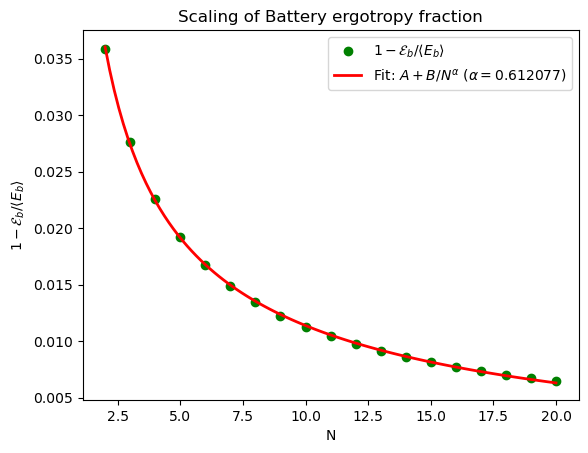

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# The fitting function
def asymptotic_fit(N, alpha, A, B):
    return (A + B / (N**alpha))


y_data = 1 - np.array(E_ratio) 

# The curve fit

popt, pcov = curve_fit(asymptotic_fit, N_arr, y_data)
alpha_opt, A_opt, B_opt = popt

print(f"Best fit parameters: A = {A_opt:.6f}, B = {B_opt:.6f}, Optimal value for alpha: {alpha_opt:.6f}")

# A smooth curve for the fit using the optimal parameters

N_smooth = np.linspace(min(N_arr), max(N_arr), 100)
y_fit = asymptotic_fit(N_smooth, alpha_opt, A_opt, B_opt)

# Plot the original data and the fitted curve

plt.plot(N_arr, y_data, 'o', color='g', markersize=6, label=r"$1 - \mathcal{E}_b / \langle E_b \rangle$")
plt.plot(N_smooth, y_fit, '-', color='r', linewidth=2, label=rf'Fit: $A + B/N^{{\alpha}}$ ($\alpha={alpha_opt:.6f}$)')

plt.xlabel("N")
plt.ylabel(r"$1 - \mathcal{E}_b / \langle E_b \rangle$")
plt.title("Scaling of Battery ergotropy fraction")
plt.legend()
# plt.savefig("OP6")
plt.show()

Best fit parameters: A = 0.039760, B = 1.111758, Optimal value for alpha: 0.664392


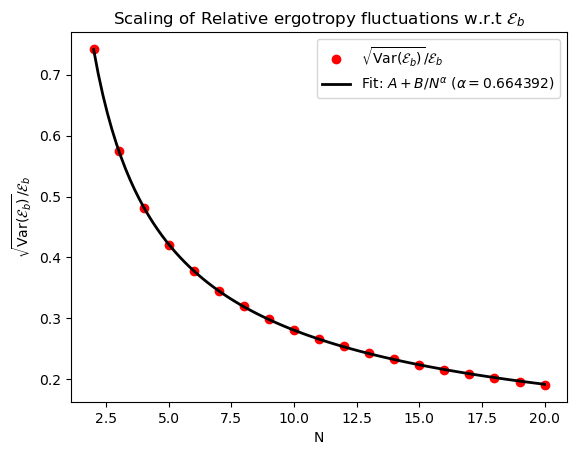

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function
def asymptotic_fit(N, alpha, A, B):
    return (A + B / (N**alpha))

y_data = np.array(F_ratio) 

# The curve fit
popt, pcov = curve_fit(asymptotic_fit, N_arr, y_data)
alpha_opt, A_opt, B_opt = popt

print(f"Best fit parameters: A = {A_opt:.6f}, B = {B_opt:.6f}, Optimal value for alpha: {alpha_opt:.6f}")

# A smooth curve for the fit using the optimal alpha

N_smooth = np.linspace(min(N_arr), max(N_arr), 100)
y_fit = asymptotic_fit(N_smooth, alpha_opt, A_opt, B_opt)

# Plot the original data and the fitted curve

plt.plot(N_arr, y_data, 'o', color='r', markersize=6, label=r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.plot(N_smooth, y_fit, '-', color='k', linewidth=2, label=rf'Fit: $A + B/N^{{\alpha}}$ ($\alpha={alpha_opt:.6f}$)')

plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Scaling of Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
plt.legend()
# plt.savefig("OP7")
plt.show()